In [2]:
import duckdb
import numpy as np
import pandas as pd

In [3]:
con = duckdb.connect(database=':memory:')

In [4]:
path =r'C:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\Data\SEDS\SEDS.txt'

In [5]:
df = con.execute(f"""
    SELECT *
    FROM read_json_auto(
        '{path}',
        union_by_name = true
    )
""").df()


In [6]:
df

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,end,last_updated,geoset_id,data
0,SEDS.B1PRP.IN.A,"Renewable diesel production, Indiana",Thousand barrels,A,"Renewable diesel production, Indiana See http:...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-IN,USA-IN,1960,2023,2026-01-09T14:48:04-05:00,SEDS.B1PRP.A,"[[""2023"", 0], [""2022"", 0], [""2021"", 0], [""2020..."
1,SEDS.B1PRP.KS.A,"Renewable diesel production, Kansas",Thousand barrels,A,"Renewable diesel production, Kansas See http:/...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-KS,USA-KS,1960,2023,2026-01-09T14:48:04-05:00,SEDS.B1PRP.A,"[[""2023"", 1515], [""2022"", 729], [""2021"", 43], ..."
2,SEDS.B1PRB.AK.A,"Renewable diesel production, Alaska",Billion Btu,A,"Renewable diesel production, Alaska See http:/...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1960,2023,2026-01-09T14:48:04-05:00,SEDS.B1PRB.A,"[[""2023"", 0], [""2022"", 0], [""2021"", 0], [""2020..."
3,SEDS.B1PRP.KY.A,"Renewable diesel production, Kentucky",Thousand barrels,A,"Renewable diesel production, Kentucky See http...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-KY,USA-KY,1960,2023,2026-01-09T14:48:04-05:00,SEDS.B1PRP.A,"[[""2023"", 0], [""2022"", 0], [""2021"", 0], [""2020..."
4,SEDS.B1PRP.LA.A,"Renewable diesel production, Louisiana",Thousand barrels,A,"Renewable diesel production, Louisiana See htt...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-LA,USA-LA,1960,2023,2026-01-09T14:48:04-05:00,SEDS.B1PRP.A,"[[""2023"", 22405], [""2022"", 18640], [""2021"", 93..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49635,None,"Wind energy, total consumed.",Billion Btu,None,None,None,None,None,None,None,None,None,SEDS.WYTCB.A,<NA>
49636,None,"Wind electricity, total net generation.",Million kilowatthours,None,None,None,None,None,None,None,None,None,SEDS.WYTCP.A,<NA>
49637,None,"Wind energy, total end-use consumption.",Billion Btu,None,None,None,None,None,None,None,None,None,SEDS.WYTXB.A,<NA>
49638,None,"Wind energy, total end-use net generation.",Million kilowatthours,None,None,None,None,None,None,None,None,None,SEDS.WYTXP.A,<NA>


In [7]:
df

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,end,last_updated,geoset_id,data
0,SEDS.B1PRP.IN.A,"Renewable diesel production, Indiana",Thousand barrels,A,"Renewable diesel production, Indiana See http:...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-IN,USA-IN,1960,2023,2026-01-09T14:48:04-05:00,SEDS.B1PRP.A,"[[""2023"", 0], [""2022"", 0], [""2021"", 0], [""2020..."
1,SEDS.B1PRP.KS.A,"Renewable diesel production, Kansas",Thousand barrels,A,"Renewable diesel production, Kansas See http:/...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-KS,USA-KS,1960,2023,2026-01-09T14:48:04-05:00,SEDS.B1PRP.A,"[[""2023"", 1515], [""2022"", 729], [""2021"", 43], ..."
2,SEDS.B1PRB.AK.A,"Renewable diesel production, Alaska",Billion Btu,A,"Renewable diesel production, Alaska See http:/...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1960,2023,2026-01-09T14:48:04-05:00,SEDS.B1PRB.A,"[[""2023"", 0], [""2022"", 0], [""2021"", 0], [""2020..."
3,SEDS.B1PRP.KY.A,"Renewable diesel production, Kentucky",Thousand barrels,A,"Renewable diesel production, Kentucky See http...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-KY,USA-KY,1960,2023,2026-01-09T14:48:04-05:00,SEDS.B1PRP.A,"[[""2023"", 0], [""2022"", 0], [""2021"", 0], [""2020..."
4,SEDS.B1PRP.LA.A,"Renewable diesel production, Louisiana",Thousand barrels,A,"Renewable diesel production, Louisiana See htt...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-LA,USA-LA,1960,2023,2026-01-09T14:48:04-05:00,SEDS.B1PRP.A,"[[""2023"", 22405], [""2022"", 18640], [""2021"", 93..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49635,None,"Wind energy, total consumed.",Billion Btu,None,None,None,None,None,None,None,None,None,SEDS.WYTCB.A,<NA>
49636,None,"Wind electricity, total net generation.",Million kilowatthours,None,None,None,None,None,None,None,None,None,SEDS.WYTCP.A,<NA>
49637,None,"Wind energy, total end-use consumption.",Billion Btu,None,None,None,None,None,None,None,None,None,SEDS.WYTXB.A,<NA>
49638,None,"Wind energy, total end-use net generation.",Million kilowatthours,None,None,None,None,None,None,None,None,None,SEDS.WYTXP.A,<NA>


In [8]:
df['data']

0        [["2023", 0], ["2022", 0], ["2021", 0], ["2020...
1        [["2023", 1515], ["2022", 729], ["2021", 43], ...
2        [["2023", 0], ["2022", 0], ["2021", 0], ["2020...
3        [["2023", 0], ["2022", 0], ["2021", 0], ["2020...
4        [["2023", 22405], ["2022", 18640], ["2021", 93...
                               ...                        
49635                                                 <NA>
49636                                                 <NA>
49637                                                 <NA>
49638                                                 <NA>
49639                                                 <NA>
Name: data, Length: 49640, dtype: object

In [11]:
# Check what columns you have
df_test = con.execute(f"""
    SELECT *
    FROM read_json_auto(
        '{path}',
        union_by_name = true
    )
    LIMIT 5
""").df()

print(df_test.columns.tolist())
print(df_test.head())

['series_id', 'name', 'units', 'f', 'description', 'copyright', 'source', 'iso3166', 'geography', 'start', 'end', 'last_updated', 'geoset_id', 'data']
         series_id                                    name             units  \
0  SEDS.B1PRP.IN.A    Renewable diesel production, Indiana  Thousand barrels   
1  SEDS.B1PRP.KS.A     Renewable diesel production, Kansas  Thousand barrels   
2  SEDS.B1PRB.AK.A     Renewable diesel production, Alaska       Billion Btu   
3  SEDS.B1PRP.KY.A   Renewable diesel production, Kentucky  Thousand barrels   
4  SEDS.B1PRP.LA.A  Renewable diesel production, Louisiana  Thousand barrels   

   f                                        description copyright  \
0  A  Renewable diesel production, Indiana See http:...      None   
1  A  Renewable diesel production, Kansas See http:/...      None   
2  A  Renewable diesel production, Alaska See http:/...      None   
3  A  Renewable diesel production, Kentucky See http...      None   
4  A  Renewable diesel 

In [13]:
df.to_csv('SEDS_Processed.csv', index=False)

In [14]:
# Load data
df = con.execute(f"""
    SELECT *
    FROM read_json_auto(
        '{path}',
        union_by_name = true
    )
""").df()

import ast

# Convert the data column to dictionaries
def parse_data(data_str):
    try:
        data_list = ast.literal_eval(data_str)
        return {str(item[0]).strip('"'): float(item[1]) for item in data_list}
    except:
        return {}

df['data_dict'] = df['data'].apply(parse_data)

# Extract specific years
years = ['2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014']
for year in years:
    df[f'year_{year}'] = df['data_dict'].apply(lambda x: x.get(year, 0))

# Clean up
# df = df.drop(['data', 'data_dict'], axis=1)

In [15]:
df

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,...,year_2023,year_2022,year_2021,year_2020,year_2019,year_2018,year_2017,year_2016,year_2015,year_2014
0,SEDS.B1PRP.IN.A,"Renewable diesel production, Indiana",Thousand barrels,A,"Renewable diesel production, Indiana See http:...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-IN,USA-IN,1960,...,0,0,0,0,0,0,0,0,0,0
1,SEDS.B1PRP.KS.A,"Renewable diesel production, Kansas",Thousand barrels,A,"Renewable diesel production, Kansas See http:/...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-KS,USA-KS,1960,...,0,0,0,0,0,0,0,0,0,0
2,SEDS.B1PRB.AK.A,"Renewable diesel production, Alaska",Billion Btu,A,"Renewable diesel production, Alaska See http:/...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1960,...,0,0,0,0,0,0,0,0,0,0
3,SEDS.B1PRP.KY.A,"Renewable diesel production, Kentucky",Thousand barrels,A,"Renewable diesel production, Kentucky See http...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-KY,USA-KY,1960,...,0,0,0,0,0,0,0,0,0,0
4,SEDS.B1PRP.LA.A,"Renewable diesel production, Louisiana",Thousand barrels,A,"Renewable diesel production, Louisiana See htt...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-LA,USA-LA,1960,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49635,None,"Wind energy, total consumed.",Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,0
49636,None,"Wind electricity, total net generation.",Million kilowatthours,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,0
49637,None,"Wind energy, total end-use consumption.",Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,0
49638,None,"Wind energy, total end-use net generation.",Million kilowatthours,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,0


In [16]:
df.columns

Index(['series_id', 'name', 'units', 'f', 'description', 'copyright', 'source',
       'iso3166', 'geography', 'start', 'end', 'last_updated', 'geoset_id',
       'data', 'data_dict', 'year_2023', 'year_2022', 'year_2021', 'year_2020',
       'year_2019', 'year_2018', 'year_2017', 'year_2016', 'year_2015',
       'year_2014'],
      dtype='object')

In [17]:
df['name'].value_counts().to_csv('name_value_counts.csv')

In [18]:
import pandas as pd
import re

# keywords to ignore
ignore_keywords = [
    "co2", "import", "export",
    "coal", "petroleum", "refinery",
    "diesel", "petrol", "gasoline",
    "biofuel", "biomass", "lignite",
    "oil", "kerosene",
    "natural gas", "emission","Geothermal","Fossil","Nuclear","Propane"
]

pattern = "|".join(ignore_keywords)

# keep rows that DO NOT contain these keywords
df_clean = df[~df["name"].str.lower().str.contains(pattern, regex=True)]

print(f"Original rows: {len(df)}")
print(f"After filtering: {len(df_clean)}")


Original rows: 49640
After filtering: 21376


In [19]:
df_clean['name'].value_counts().to_csv('name_value_counts_cleaned.csv')

In [20]:
keep_pattern = r"(solar|photovoltaic|pv|electricity total consumption|electricity consumed)"

drop_pattern = (
    r"wind|hydro|geothermal|nuclear|"
    r"jet fuel|ethanol|propane|hydrocarbon|"
    r"coal|gas|petroleum|biomass|waste|"
    r"physical units|conversion|per capita|"
    r"energy losses|primary energy"
)

df_solar = df[
    df["name"].str.lower().str.contains(keep_pattern, regex=True) &
    ~df["name"].str.lower().str.contains(drop_pattern, regex=True)
]


C:\Users\Shaaf\AppData\Local\Temp\ipykernel_15620\947775849.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["name"].str.lower().str.contains(keep_pattern, regex=True) &


In [21]:
df_solar

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,...,year_2023,year_2022,year_2021,year_2020,year_2019,year_2018,year_2017,year_2016,year_2015,year_2014
2764,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,0,0,0,0
2765,SEDS.SOICB.MS.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-MS,USA-MS,1960,...,0,0,0,0,0,0,0,0,0,0
2766,SEDS.SOICB.MT.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-MT,USA-MT,1960,...,0,0,0,0,0,0,0,0,0,0
2767,SEDS.SOICB.NC.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-NC,USA-NC,1960,...,0,0,0,0,0,0,0,0,0,0
2768,SEDS.SOICB.ND.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-ND,USA-ND,1960,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49548,None,Photovoltaic and solar thermal electricity net...,Million kilowatthours,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,0
49549,None,Distributed photovoltaic and solar thermal ene...,Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,0
49550,None,Photovoltaic and solar thermal energy consumed...,Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,0
49551,None,"Photovoltaic and solar thermal energy, total c...",Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,0


In [22]:
df_solar['name'].value_counts().to_csv('name_value_counts_solar.csv')

In [23]:
import numpy as np

gen_pattern = r"generation|generated|produced|production"
con_pattern = r"consumption|consumed|consuming|sales to ultimate customers|electricity sales|end-use"

def classify_energy_flow(name):
    name = name.lower()
    if re.search(gen_pattern, name):
        return "generation"
    elif re.search(con_pattern, name):
        return "consumption"
    else:
        return "other"

df_solar["energy_flow_type"] = df_solar["name"].apply(classify_energy_flow)


C:\Users\Shaaf\AppData\Local\Temp\ipykernel_15620\48042706.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_solar["energy_flow_type"] = df_solar["name"].apply(classify_energy_flow)


In [24]:
df_solar

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,...,year_2022,year_2021,year_2020,year_2019,year_2018,year_2017,year_2016,year_2015,year_2014,energy_flow_type
2764,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,0,0,0,generation
2765,SEDS.SOICB.MS.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-MS,USA-MS,1960,...,0,0,0,0,0,0,0,0,0,consumption
2766,SEDS.SOICB.MT.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-MT,USA-MT,1960,...,0,0,0,0,0,0,0,0,0,consumption
2767,SEDS.SOICB.NC.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-NC,USA-NC,1960,...,0,0,0,0,0,0,0,0,0,consumption
2768,SEDS.SOICB.ND.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-ND,USA-ND,1960,...,0,0,0,0,0,0,0,0,0,consumption
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49548,None,Photovoltaic and solar thermal electricity net...,Million kilowatthours,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,generation
49549,None,Distributed photovoltaic and solar thermal ene...,Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,generation
49550,None,Photovoltaic and solar thermal energy consumed...,Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,consumption
49551,None,"Photovoltaic and solar thermal energy, total c...",Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,0,consumption


In [25]:
df_solar["energy_flow_type"].value_counts()

energy_flow_type
consumption    1055
generation      368
other           161
Name: count, dtype: int64

In [26]:
df_solar.to_csv('SEDS_Solar_Cleaned & Processed.csv', index=False)

In [27]:
df_solar["state"] = (
    df_solar["name"]
    .str.split(",", n=1)
    .str[-1]
    .str.strip()
)

C:\Users\Shaaf\AppData\Local\Temp\ipykernel_15620\2034940508.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_solar["state"] = (


In [28]:
df_solar

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,...,year_2021,year_2020,year_2019,year_2018,year_2017,year_2016,year_2015,year_2014,energy_flow_type,state
2764,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,0,0,generation,Maryland
2765,SEDS.SOICB.MS.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-MS,USA-MS,1960,...,0,0,0,0,0,0,0,0,consumption,Mississippi
2766,SEDS.SOICB.MT.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-MT,USA-MT,1960,...,0,0,0,0,0,0,0,0,consumption,Montana
2767,SEDS.SOICB.NC.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-NC,USA-NC,1960,...,0,0,0,0,0,0,0,0,consumption,North Carolina
2768,SEDS.SOICB.ND.A,Solar energy consumed by the industrial sector...,Billion Btu,A,Solar energy consumed by the industrial sector...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-ND,USA-ND,1960,...,0,0,0,0,0,0,0,0,consumption,North Dakota
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49548,None,Photovoltaic and solar thermal electricity net...,Million kilowatthours,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,generation,Photovoltaic and solar thermal electricity net...
49549,None,Distributed photovoltaic and solar thermal ene...,Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,generation,"commercial, and industrial sectors, other than..."
49550,None,Photovoltaic and solar thermal energy consumed...,Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,consumption,Photovoltaic and solar thermal energy consumed...
49551,None,"Photovoltaic and solar thermal energy, total c...",Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,consumption,total consumed.


In [29]:
df_solar["state"].value_counts()

state
Maryland                                                                                                                                          30
Mississippi                                                                                                                                       30
Montana                                                                                                                                           30
North Carolina                                                                                                                                    30
North Dakota                                                                                                                                      30
                                                                                                                                                  ..
Photovoltaic and solar thermal electricity net generation in the electric power sector.             

In [30]:
df_solar['name'].value_counts().to_csv('name_value_counts_solar.csv')

In [31]:
solar_energy_generation = df_solar[df_solar["energy_flow_type"] == "generation"]

In [32]:
solar_energy_generation

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,...,year_2021,year_2020,year_2019,year_2018,year_2017,year_2016,year_2015,year_2014,energy_flow_type,state
2764,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,0,0,generation,Maryland
2770,SEDS.SOPRB.WY.A,"Solar energy production, Wyoming",Billion Btu,A,"Solar energy production, Wyoming See http://ww...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-WY,USA-WY,1960,...,0,0,0,0,0,0,0,0,generation,Wyoming
2771,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,...,0,0,0,0,0,0,0,0,generation,Alaska
2772,SEDS.SOR7P.AL.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AL,USA-AL,1989,...,0,0,0,0,0,0,0,0,generation,Alabama
2773,SEDS.SOR7P.AR.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AR,USA-AR,1989,...,0,0,0,0,0,0,0,0,generation,Arkansas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4619,SEDS.SOTGP.WV.A,Solar thermal and photovoltaic electricity tot...,Million kilowatthours,A,Solar thermal and photovoltaic electricity tot...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-WV,USA-WV,1960,...,0,0,0,0,0,0,0,0,generation,West Virginia
48441,None,Electricity Produced from Solar,None,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,generation,Electricity Produced from Solar
49547,None,Photovoltaic and solar thermal energy consumed...,Billion Btu,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,generation,Photovoltaic and solar thermal energy consumed...
49548,None,Photovoltaic and solar thermal electricity net...,Million kilowatthours,None,None,None,None,None,None,None,...,0,0,0,0,0,0,0,0,generation,Photovoltaic and solar thermal electricity net...


In [33]:
solar_energy_generation['data']

2764     [["2024", 8696], ["2023", 8045], ["2022", 6927...
2770     [["2024", 1557], ["2023", 692], ["2022", 715],...
2771     [["2024", 14], ["2023", 12], ["2022", 10], ["2...
2772     [["2024", 7], ["2023", 5], ["2022", 5], ["2021...
2773     [["2024", 259], ["2023", 208], ["2022", 123], ...
                               ...                        
4619     [["2024", 247], ["2023", 47], ["2022", 33], ["...
48441                                                 <NA>
49547                                                 <NA>
49548                                                 <NA>
49549                                                 <NA>
Name: data, Length: 368, dtype: object

In [34]:
# Method 1: Convert to wide format (each year as a column)
def parse_array_column(df, col_name):
    # Handle string representation of arrays
    df[col_name] = df[col_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    
    # Convert array to dictionary format
    df_expanded = df[col_name].apply(
        lambda x: {year: value for year, value in x} if isinstance(x, list) and len(x) > 0 else {}
    )
    
    # Convert to dataframe
    expanded_df = pd.DataFrame(df_expanded.tolist(), index=df.index)
    
    # Combine with original dataframe
    result = pd.concat([df.drop(columns=[col_name]), expanded_df], axis=1)
    
    return result

# Apply the function


In [35]:
result = parse_array_column(solar_energy_generation.copy(), 'data')
print(result)

             series_id                                               name  \
2764   SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
2770   SEDS.SOPRB.WY.A                   Solar energy production, Wyoming   
2771   SEDS.SOR7P.AK.A  Solar photovoltaic electricity generation by s...   
2772   SEDS.SOR7P.AL.A  Solar photovoltaic electricity generation by s...   
2773   SEDS.SOR7P.AR.A  Solar photovoltaic electricity generation by s...   
...                ...                                                ...   
4619   SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   
48441             None                    Electricity Produced from Solar   
49547             None  Photovoltaic and solar thermal energy consumed...   
49548             None  Photovoltaic and solar thermal electricity net...   
49549             None  Distributed photovoltaic and solar thermal ene...   

                       units     f  \
2764             Billion Btu     A   

In [38]:
import pandas as pd
import numpy as np

def parse_array_column(df, col_name):
    # Handle different data types more carefully
    def safe_parse(x):
        # Handle NaN
        if pd.isna(x):
            return []
        # If already a list, return it
        if isinstance(x, list):
            return x
        # If string, try to evaluate
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)
            except:
                return []
        return []
    
    # Apply safe parsing
    df[col_name] = df[col_name].apply(safe_parse)
    
    # Convert array to dictionary format
    df_expanded = df[col_name].apply(
        lambda x: {str(year): value for year, value in x} if isinstance(x, list) and len(x) > 0 else {}
    )
    
    # Convert to dataframe
    expanded_df = pd.DataFrame(df_expanded.tolist(), index=df.index)
    
    # Combine with original dataframe
    result = pd.concat([df.drop(columns=[col_name]), expanded_df], axis=1)
    
    return result

# Apply the function
# result = parse_array_column(solar_energy_generation.copy(), 'data')
# print(result)

In [40]:
import pandas as pd
import numpy as np

# Create a copy
df_result = solar_energy_generation.copy()

# Explode the data column
df_result = df_result.explode('data')

# Remove rows with NaN or empty data
df_result = df_result[df_result['data'].notna()]
df_result = df_result[df_result['data'].apply(lambda x: len(x) > 0 if isinstance(x, (list, np.ndarray)) else False)]

# Split into year and value columns
df_result['year'] = df_result['data'].apply(lambda x: x[0] if len(x) > 0 else None)
df_result['value'] = df_result['data'].apply(lambda x: x[1] if len(x) > 1 else None)

# Drop the original data column
df_result = df_result.drop(columns=['data'])

print(df_result)

            series_id                                               name  \
2764  SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
2764  SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
2764  SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
2764  SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
2764  SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
...               ...                                                ...   
4619  SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   
4619  SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   
4619  SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   
4619  SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   
4619  SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   

                      units  f  \
2764            Billion Btu  A   
2764            Bil

In [41]:
df_result

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,...,year_2019,year_2018,year_2017,year_2016,year_2015,year_2014,energy_flow_type,state,year,value
2764,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,generation,Maryland,"""2024""",8696
2764,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,generation,Maryland,"""2023""",8045
2764,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,generation,Maryland,"""2022""",6927
2764,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,generation,Maryland,"""2021""",5769
2764,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,generation,Maryland,"""2020""",5308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4619,SEDS.SOTGP.WV.A,Solar thermal and photovoltaic electricity tot...,Million kilowatthours,A,Solar thermal and photovoltaic electricity tot...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-WV,USA-WV,1960,...,0,0,0,0,0,0,generation,West Virginia,"""1964""",0
4619,SEDS.SOTGP.WV.A,Solar thermal and photovoltaic electricity tot...,Million kilowatthours,A,Solar thermal and photovoltaic electricity tot...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-WV,USA-WV,1960,...,0,0,0,0,0,0,generation,West Virginia,"""1963""",0
4619,SEDS.SOTGP.WV.A,Solar thermal and photovoltaic electricity tot...,Million kilowatthours,A,Solar thermal and photovoltaic electricity tot...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-WV,USA-WV,1960,...,0,0,0,0,0,0,generation,West Virginia,"""1962""",0
4619,SEDS.SOTGP.WV.A,Solar thermal and photovoltaic electricity tot...,Million kilowatthours,A,Solar thermal and photovoltaic electricity tot...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-WV,USA-WV,1960,...,0,0,0,0,0,0,generation,West Virginia,"""1961""",0


In [42]:
def to_long_format(df, array_col):
    rows = []
    
    for idx, row in df.iterrows():
        data = row[array_col]
        
        # Handle NaN - use try/except for arrays
        try:
            if data is None or (isinstance(data, float) and pd.isna(data)):
                continue
        except:
            pass
        
        # Handle empty lists/arrays
        if isinstance(data, (list, np.ndarray)) and len(data) == 0:
            continue
            
        # Handle lists/arrays with data
        if isinstance(data, (list, np.ndarray)):
            for item in data:
                if isinstance(item, (list, np.ndarray)) and len(item) == 2:
                    new_row = row.drop(array_col).to_dict()
                    new_row['year'] = item[0]
                    new_row['value'] = item[1]
                    rows.append(new_row)
    
    return pd.DataFrame(rows)

# Apply long format
result_long = to_long_format(solar_energy_generation, 'data')
print(result_long)

             series_id                                               name  \
0      SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
1      SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
2      SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
3      SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
4      SEDS.SOPRB.MD.A                  Solar energy production, Maryland   
...                ...                                                ...   
22147  SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   
22148  SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   
22149  SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   
22150  SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   
22151  SEDS.SOTGP.WV.A  Solar thermal and photovoltaic electricity tot...   

                       units  f  \
0                Billion Btu  A   
1    

In [50]:
generation_result_long = pd.DataFrame(result_long)
generation_result_long

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,...,year_2019,year_2018,year_2017,year_2016,year_2015,year_2014,energy_flow_type,state,year,value
0,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,generation,Maryland,"""2024""",8696
1,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,generation,Maryland,"""2023""",8045
2,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,generation,Maryland,"""2022""",6927
3,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,generation,Maryland,"""2021""",5769
4,SEDS.SOPRB.MD.A,"Solar energy production, Maryland",Billion Btu,A,"Solar energy production, Maryland See http://w...",None,"SEDS, EIA, U.S. Energy Information Administration",USA-MD,USA-MD,1960,...,0,0,0,0,0,0,generation,Maryland,"""2020""",5308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22147,SEDS.SOTGP.WV.A,Solar thermal and photovoltaic electricity tot...,Million kilowatthours,A,Solar thermal and photovoltaic electricity tot...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-WV,USA-WV,1960,...,0,0,0,0,0,0,generation,West Virginia,"""1964""",0
22148,SEDS.SOTGP.WV.A,Solar thermal and photovoltaic electricity tot...,Million kilowatthours,A,Solar thermal and photovoltaic electricity tot...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-WV,USA-WV,1960,...,0,0,0,0,0,0,generation,West Virginia,"""1963""",0
22149,SEDS.SOTGP.WV.A,Solar thermal and photovoltaic electricity tot...,Million kilowatthours,A,Solar thermal and photovoltaic electricity tot...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-WV,USA-WV,1960,...,0,0,0,0,0,0,generation,West Virginia,"""1962""",0
22150,SEDS.SOTGP.WV.A,Solar thermal and photovoltaic electricity tot...,Million kilowatthours,A,Solar thermal and photovoltaic electricity tot...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-WV,USA-WV,1960,...,0,0,0,0,0,0,generation,West Virginia,"""1961""",0


In [56]:
solar_energy_generation.to_csv('SEDS_Solar_Energy_Generation_Long_Format.csv', index=False)

In [51]:
generation_result_long['year'] = generation_result_long['year'].str.replace(r'\D', '', regex=True)

In [52]:
generation_result_long.drop(columns=['year_2023', 'year_2022', 'year_2021', 'year_2020',
       'year_2019', 'year_2018', 'year_2017', 'year_2016', 'year_2015',
       'year_2014'], inplace=True)

In [53]:
generation_result_long.columns

Index(['series_id', 'name', 'units', 'f', 'description', 'copyright', 'source',
       'iso3166', 'geography', 'start', 'end', 'last_updated', 'geoset_id',
       'data_dict', 'energy_flow_type', 'state', 'year', 'value'],
      dtype='object')

In [55]:
generation_result_long['units'].unique()

array(['Billion Btu', 'Million kilowatthours'], dtype=object)

In [58]:
generation_result_long[['New Desription','New State']]=generation_result_long['name'].str.split(',',expand=True)

In [60]:
generation_result_long['New Desription'].unique()

array(['Solar energy production',
       'Solar photovoltaic electricity generation by small-scale applications in the residential sector',
       'Solar thermal and photovoltaic electricity net generation in the industrial sector',
       'Solar thermal and photovoltaic electricity net generation in the electric power sector',
       'Solar thermal and photovoltaic electricity net generation in the commercial sector',
       'Solar energy consumed for electricity generation by the electric power sector',
       'Solar thermal and photovoltaic electricity total net generation'],
      dtype=object)

In [61]:
keep_descriptions = [
    "Solar photovoltaic electricity generation by small-scale applications in the residential sector",
    "Solar thermal and photovoltaic electricity net generation in the industrial sector",
    "Solar thermal and photovoltaic electricity net generation in the electric power sector",
    "Solar thermal and photovoltaic electricity net generation in the commercial sector"
]


In [63]:
df_clean = generation_result_long[generation_result_long["New Desription"].isin(keep_descriptions)].copy()

In [64]:
df_clean

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,end,last_updated,geoset_id,data_dict,energy_flow_type,state,year,value,New Desription,New State
130,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,2024,2026-01-09T14:48:04-05:00,SEDS.SOR7P.A,{},generation,Alaska,2024,14,Solar photovoltaic electricity generation by s...,Alaska
131,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,2024,2026-01-09T14:48:04-05:00,SEDS.SOR7P.A,{},generation,Alaska,2023,12,Solar photovoltaic electricity generation by s...,Alaska
132,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,2024,2026-01-09T14:48:04-05:00,SEDS.SOR7P.A,{},generation,Alaska,2022,10,Solar photovoltaic electricity generation by s...,Alaska
133,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,2024,2026-01-09T14:48:04-05:00,SEDS.SOR7P.A,{},generation,Alaska,2021,8,Solar photovoltaic electricity generation by s...,Alaska
134,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,2024,2026-01-09T14:48:04-05:00,SEDS.SOR7P.A,{},generation,Alaska,2020,5,Solar photovoltaic electricity generation by s...,Alaska
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18767,SEDS.SOICP.GA.A,Solar thermal and photovoltaic electricity net...,Million kilowatthours,A,Solar thermal and photovoltaic electricity net...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-GA,USA-GA,1960,2024,2026-01-09T14:48:04-05:00,SEDS.SOICP.A,{},generation,Georgia,1964,0,Solar thermal and photovoltaic electricity net...,Georgia
18768,SEDS.SOICP.GA.A,Solar thermal and photovoltaic electricity net...,Million kilowatthours,A,Solar thermal and photovoltaic electricity net...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-GA,USA-GA,1960,2024,2026-01-09T14:48:04-05:00,SEDS.SOICP.A,{},generation,Georgia,1963,0,Solar thermal and photovoltaic electricity net...,Georgia
18769,SEDS.SOICP.GA.A,Solar thermal and photovoltaic electricity net...,Million kilowatthours,A,Solar thermal and photovoltaic electricity net...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-GA,USA-GA,1960,2024,2026-01-09T14:48:04-05:00,SEDS.SOICP.A,{},generation,Georgia,1962,0,Solar thermal and photovoltaic electricity net...,Georgia
18770,SEDS.SOICP.GA.A,Solar thermal and photovoltaic electricity net...,Million kilowatthours,A,Solar thermal and photovoltaic electricity net...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-GA,USA-GA,1960,2024,2026-01-09T14:48:04-05:00,SEDS.SOICP.A,{},generation,Georgia,1961,0,Solar thermal and photovoltaic electricity net...,Georgia


In [65]:
df_clean["New Desription"].value_counts()

New Desription
Solar thermal and photovoltaic electricity net generation in the industrial sector                 3380
Solar thermal and photovoltaic electricity net generation in the electric power sector             3380
Solar thermal and photovoltaic electricity net generation in the commercial sector                 3380
Solar photovoltaic electricity generation by small-scale applications in the residential sector    1872
Name: count, dtype: int64

In [66]:
sector_map = {
    "Solar photovoltaic electricity generation by small-scale applications in the residential sector": "Residential",
    "Solar thermal and photovoltaic electricity net generation in the commercial sector": "Commercial",
    "Solar thermal and photovoltaic electricity net generation in the electric power sector": "Utility",
    "Solar thermal and photovoltaic electricity net generation in the industrial sector": "Industry"
}
df_clean['Sector'] = df_clean['New Desription'].map(sector_map)

In [67]:
df_clean

,series_id,name,units,f,description,copyright,source,iso3166,geography,start,...,last_updated,geoset_id,data_dict,energy_flow_type,state,year,value,New Desription,New State,Sector
130,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,...,2026-01-09T14:48:04-05:00,SEDS.SOR7P.A,{},generation,Alaska,2024,14,Solar photovoltaic electricity generation by s...,Alaska,Residential
131,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,...,2026-01-09T14:48:04-05:00,SEDS.SOR7P.A,{},generation,Alaska,2023,12,Solar photovoltaic electricity generation by s...,Alaska,Residential
132,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,...,2026-01-09T14:48:04-05:00,SEDS.SOR7P.A,{},generation,Alaska,2022,10,Solar photovoltaic electricity generation by s...,Alaska,Residential
133,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,...,2026-01-09T14:48:04-05:00,SEDS.SOR7P.A,{},generation,Alaska,2021,8,Solar photovoltaic electricity generation by s...,Alaska,Residential
134,SEDS.SOR7P.AK.A,Solar photovoltaic electricity generation by s...,Million kilowatthours,A,Solar photovoltaic electricity generation by s...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-AK,USA-AK,1989,...,2026-01-09T14:48:04-05:00,SEDS.SOR7P.A,{},generation,Alaska,2020,5,Solar photovoltaic electricity generation by s...,Alaska,Residential
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18767,SEDS.SOICP.GA.A,Solar thermal and photovoltaic electricity net...,Million kilowatthours,A,Solar thermal and photovoltaic electricity net...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-GA,USA-GA,1960,...,2026-01-09T14:48:04-05:00,SEDS.SOICP.A,{},generation,Georgia,1964,0,Solar thermal and photovoltaic electricity net...,Georgia,Industry
18768,SEDS.SOICP.GA.A,Solar thermal and photovoltaic electricity net...,Million kilowatthours,A,Solar thermal and photovoltaic electricity net...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-GA,USA-GA,1960,...,2026-01-09T14:48:04-05:00,SEDS.SOICP.A,{},generation,Georgia,1963,0,Solar thermal and photovoltaic electricity net...,Georgia,Industry
18769,SEDS.SOICP.GA.A,Solar thermal and photovoltaic electricity net...,Million kilowatthours,A,Solar thermal and photovoltaic electricity net...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-GA,USA-GA,1960,...,2026-01-09T14:48:04-05:00,SEDS.SOICP.A,{},generation,Georgia,1962,0,Solar thermal and photovoltaic electricity net...,Georgia,Industry
18770,SEDS.SOICP.GA.A,Solar thermal and photovoltaic electricity net...,Million kilowatthours,A,Solar thermal and photovoltaic electricity net...,None,"SEDS, EIA, U.S. Energy Information Administration",USA-GA,USA-GA,1960,...,2026-01-09T14:48:04-05:00,SEDS.SOICP.A,{},generation,Georgia,1961,0,Solar thermal and photovoltaic electricity net...,Georgia,Industry


In [71]:
df_clean['value']=df_clean['value'].astype(float)

In [72]:
new_data = df_clean.groupby(['Sector', 'year'], as_index=False)['value'].sum()

In [87]:
new_data.to_csv('SEDS_Solar_Energy_Generation_By_Sector_Year.csv', index=False)

In [74]:
new_data.set_index('year', inplace=True)

In [75]:
new_data

,Sector,value
year,,
1960,Commercial,0.0
1961,Commercial,0.0
1962,Commercial,0.0
1963,Commercial,0.0
1964,Commercial,0.0
...,...,...
2020,Utility,177025.0
2021,Utility,229046.0
2022,Utility,285693.0


In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
new_data=new_data[new_data['value']>0]

In [82]:
new_data.sort_index(inplace=True)

C:\Users\Shaaf\AppData\Local\Temp\ipykernel_15620\1967861637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data.sort_index(inplace=True)


In [85]:
new_data=new_data[new_data.index>'2005']

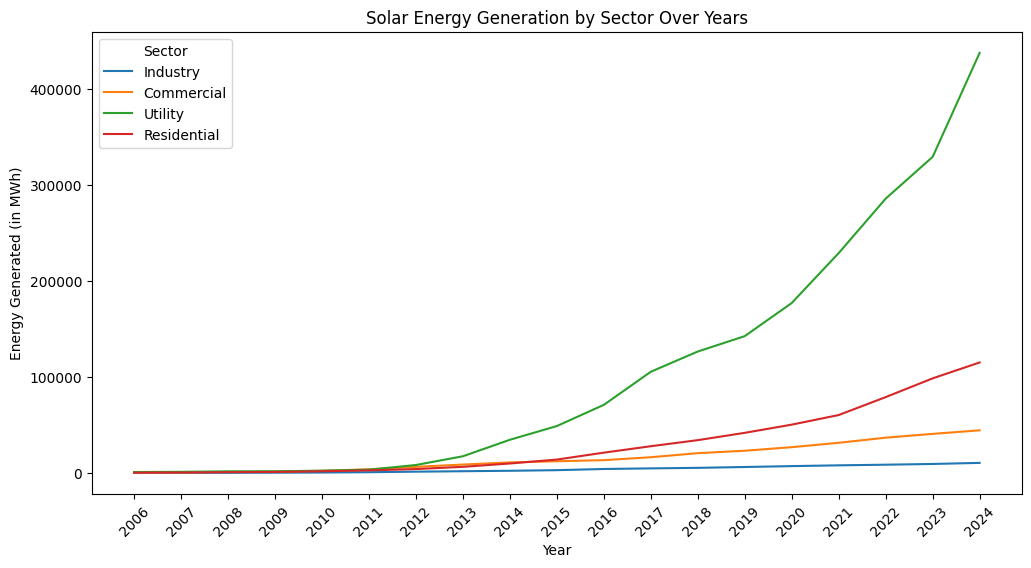

In [86]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=new_data, x=new_data.index, y='value', hue='Sector')
plt.title('Solar Energy Generation by Sector Over Years')
plt.xlabel('Year')
plt.ylabel('Energy Generated (in MWh)')
plt.xticks(rotation=45)
plt.legend(title='Sector')
plt.show()